# Анализ трафика веб-сайта: выявление паттернов пользовательской активности

Задача: на основе данных о сессиях пользователей веб-сайта электронной коммерции выявить паттерны активности — временные, поведенческие, по источникам трафика и устройствам.

Датасет содержит 105 847 записей за период июнь–ноябрь 2025 года.

## 1. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv('web_traffic_data.csv')
df.head()

,session_id,timestamp,user_id,page_url,traffic_source,device_type,geo_location,page_duration,pages_viewed,conversion
0,sess_000001,2025-11-11 11:47:17,user_05698,/search,referral,desktop,Chelyabinsk,56.4,2,0
1,sess_000002,2025-10-30 21:01:05,user_46926,/cart,social,desktop,Moscow,61.5,2,0
2,sess_000003,2025-10-23 10:14:28,user_45754,/product,direct,mobile,Saint Petersburg,75.1,1,1
3,sess_000004,2025-09-17 11:09:13,user_23527,/catalog,direct,desktop,Moscow,878.2,25,1
4,sess_000005,2025-09-05 17:46:29,user_19214,/search,organic,mobile,Other,165.7,2,0


## 2. Первичный анализ данных

In [3]:
def dataframe_info(df):
    print('Размер:', df.shape)
    print('Info:')
    df.info()
    print('Пропущенные значения:')
    print(df.isna().sum())
    print('Дубликаты:', df.duplicated().sum())

dataframe_info(df)

Размер: (105847, 10)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105847 entries, 0 to 105846
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   session_id      105847 non-null  object 
 1   timestamp       105847 non-null  object 
 2   user_id         105847 non-null  object 
 3   page_url        105847 non-null  object 
 4   traffic_source  105847 non-null  object 
 5   device_type     105847 non-null  object 
 6   geo_location    103727 non-null  object 
 7   page_duration   105282 non-null  float64
 8   pages_viewed    105847 non-null  int64  
 9   conversion      105847 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 8.1+ MB
Пропущенные значения:
session_id           0
timestamp            0
user_id              0
page_url             0
traffic_source       0
device_type          0
geo_location      2120
page_duration      565
pages_viewed         0
conversion         

## 3. Предобработка данных

In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

df['geo_location'] = df['geo_location'].fillna('Unknown')
df['page_duration'] = df['page_duration'].fillna(df['page_duration'].median())

Из признака `timestamp` извлечены производные признаки: час посещения, день недели и месяц — для анализа временных паттернов.

Пропуски в `geo_location` заменены на `Unknown`, в `page_duration` — на медианное значение.

## 4. Анализ целевого признака — конверсии

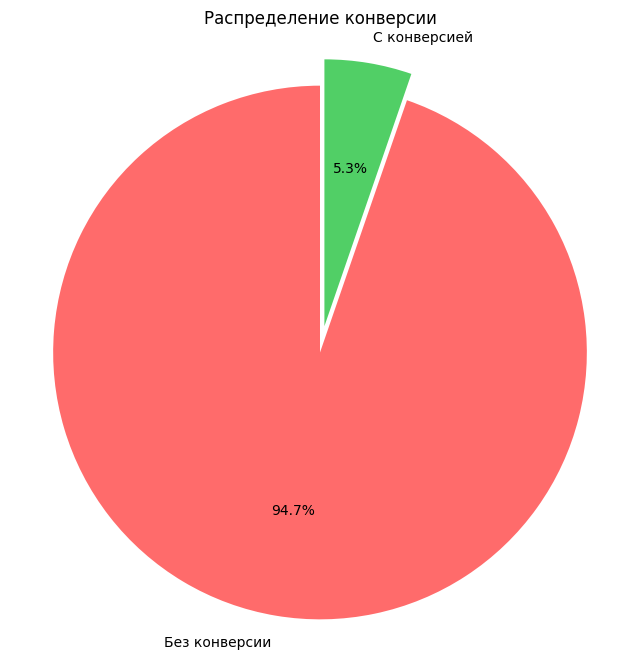

In [5]:
plt.figure(figsize=(8, 8))
conversion_counts = df['conversion'].value_counts()
colors_conv = ['#ff6b6b', '#51cf66']
labels = ['Без конверсии', 'С конверсией']
plt.pie(conversion_counts, labels=labels, autopct='%1.1f%%',
        startangle=90, colors=colors_conv, explode=(0, 0.1))
plt.title('Распределение конверсии')
plt.axis('equal')
plt.show()

Классы несбалансированы: большинство сессий завершается без конверсии.

Это важно учитывать при дальнейшем анализе — оценка качества по точности (accuracy) была бы некорректна.

## 5. Анализ источников трафика

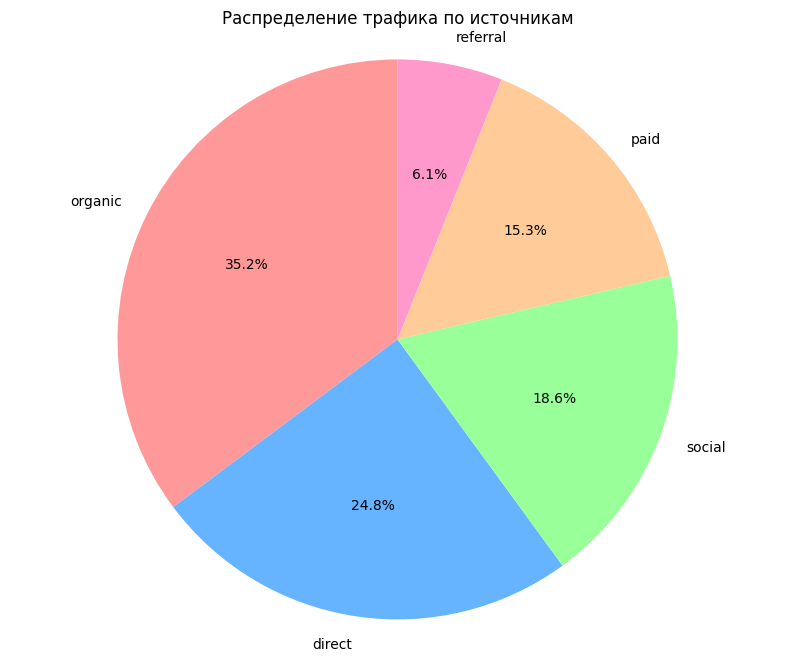

In [6]:
plt.figure(figsize=(10, 8))
traffic_counts = df['traffic_source'].value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
plt.pie(traffic_counts, labels=traffic_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors)
plt.title('Распределение трафика по источникам')
plt.axis('equal')
plt.show()

Наибольшую долю трафика формирует органический поиск (35,2%), за ним следуют прямые переходы (24,8%) и социальные сети (18,6%).

Реферальный трафик составляет наименьшую долю (6,1%).

/tmp/ipykernel_44051/975462210.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_by_source.index, y=conversion_by_source.values, palette='coolwarm')


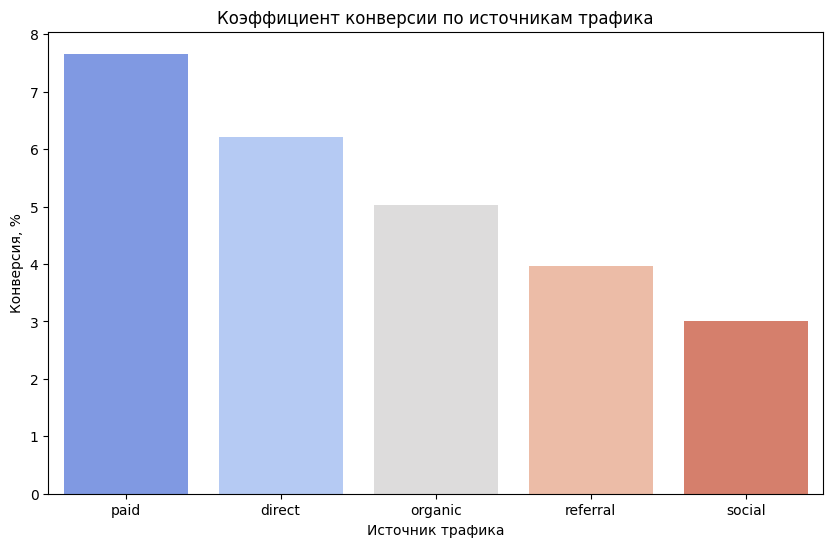

In [7]:
conversion_by_source = df.groupby('traffic_source')['conversion'].mean() * 100
conversion_by_source = conversion_by_source.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=conversion_by_source.index, y=conversion_by_source.values, palette='coolwarm')
plt.title('Коэффициент конверсии по источникам трафика')
plt.xlabel('Источник трафика')
plt.ylabel('Конверсия, %')
plt.show()

Платная реклама демонстрирует наилучший коэффициент конверсии (7,66%), за ней следуют прямые переходы (6,21%) и органический поиск (5,03%).

Трафик из социальных сетей имеет наибольший объём, но самый низкий коэффициент конверсии (3,00%) — это указывает на необходимость улучшения посадочных страниц для аудитории из соцсетей.

## 6. Анализ типов устройств

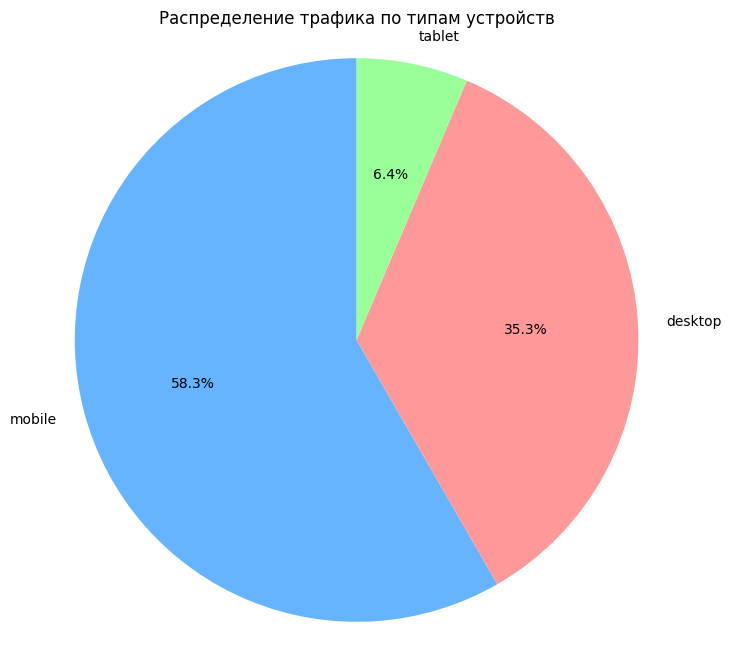

In [8]:
device_counts = df['device_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(device_counts, labels=device_counts.index, autopct='%1.1f%%',
        startangle=90, colors=['#66b3ff', '#ff9999', '#99ff99'])
plt.title('Распределение трафика по типам устройств')
plt.axis('equal')
plt.show()

/tmp/ipykernel_44051/4061553256.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conversion_by_device.index, y=conversion_by_device.values, palette='Blues_d')


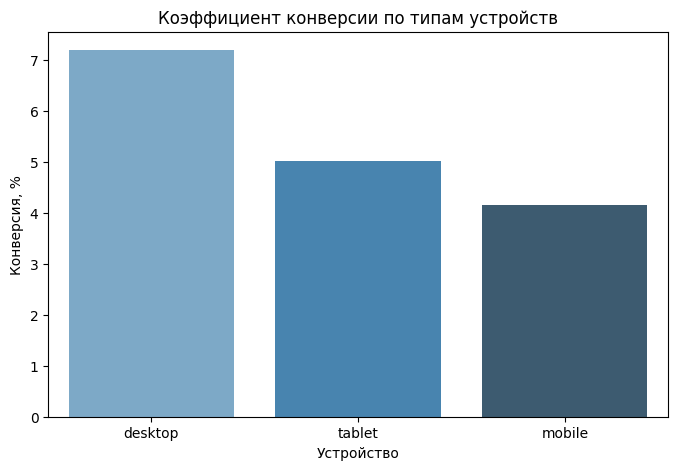

In [9]:
conversion_by_device = df.groupby('device_type')['conversion'].mean() * 100
conversion_by_device = conversion_by_device.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=conversion_by_device.index, y=conversion_by_device.values, palette='Blues_d')
plt.title('Коэффициент конверсии по типам устройств')
plt.xlabel('Устройство')
plt.ylabel('Конверсия, %')
plt.show()

Мобильный трафик преобладает (58,3%), однако коэффициент конверсии на десктопных устройствах значительно выше: desktop — 7,20%, tablet — 5,03%, mobile — 4,15%.

Это указывает на необходимость оптимизации мобильной версии сайта для повышения конверсии.

## 7. Анализ временных паттернов

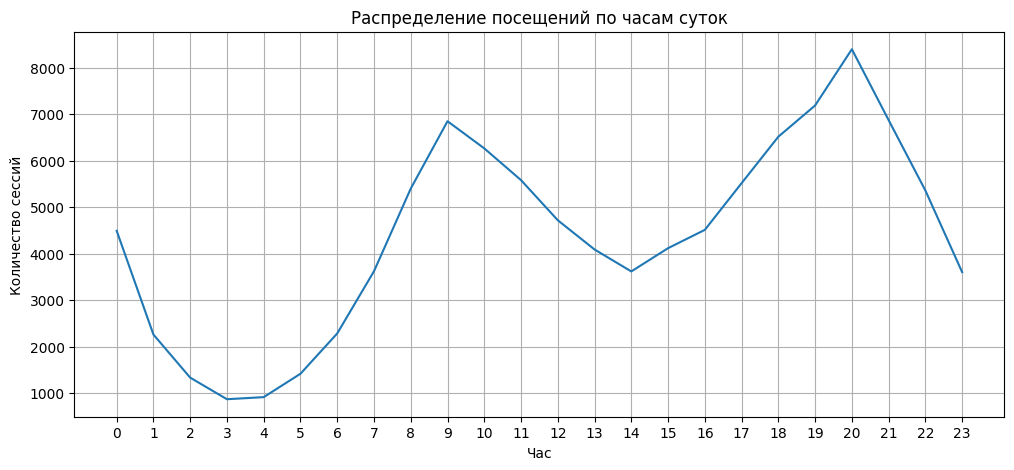

In [10]:
hourly = df.groupby('hour').size()

plt.figure(figsize=(12, 5))
sns.lineplot(x=hourly.index, y=hourly.values)
plt.title('Распределение посещений по часам суток')
plt.xlabel('Час')
plt.ylabel('Количество сессий')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Выявлены два пика активности: основной — в вечерние часы (19:00–21:00, максимум в 20:00 — 7,9% всех сессий) и второстепенный — в утренние часы (9:00 — 6,5%).

Минимальная активность наблюдается в ночные часы: 3:00–4:00 (менее 1% сессий).

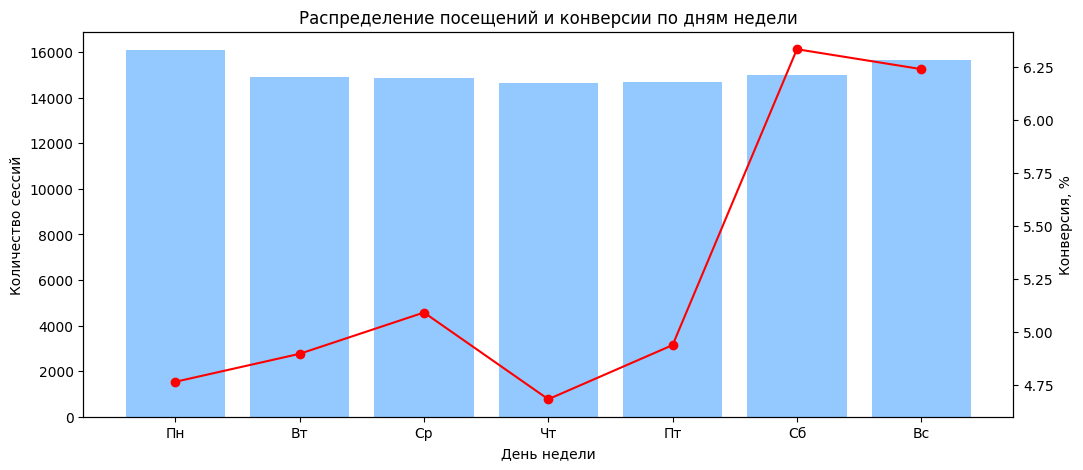

In [11]:
days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
daily = df.groupby('day_of_week').size()
daily_conv = df.groupby('day_of_week')['conversion'].mean() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(daily.index, daily.values, color='#66b3ff', alpha=0.7, label='Сессии')
ax2.plot(daily_conv.index, daily_conv.values, color='red', marker='o', label='Конверсия %')

ax1.set_xlabel('День недели')
ax1.set_ylabel('Количество сессий')
ax2.set_ylabel('Конверсия, %')
ax1.set_xticks(range(7))
ax1.set_xticklabels(days)
plt.title('Распределение посещений и конверсии по дням недели')
plt.show()

Наибольшая активность наблюдается в понедельник (15,2%) и воскресенье (14,8%).

Коэффициент конверсии в выходные дни (6,29%) превышает показатель будних дней (4,87%) — пользователи в выходные более склонны к совершению покупок.

/tmp/ipykernel_44051/2733267009.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly.index, y=monthly.values, palette='autumn')


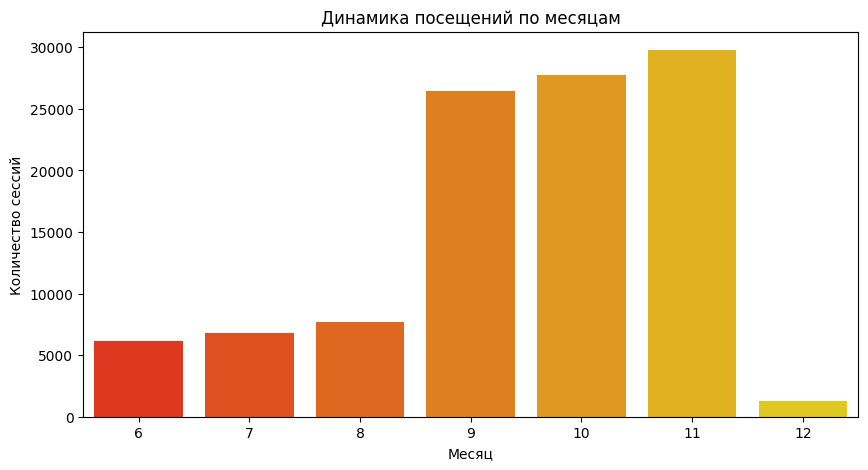

In [12]:
monthly = df.groupby('month').size()

plt.figure(figsize=(10, 5))
sns.barplot(x=monthly.index, y=monthly.values, palette='autumn')
plt.title('Динамика посещений по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество сессий')
plt.show()

Наблюдается выраженный сезонный рост трафика в осенний период: сентябрь — 25,0%, октябрь — 26,2%, ноябрь — 28,1% всех сессий.

В летние месяцы (июнь–август) трафик значительно ниже. Это может быть связано с сезонностью спроса или маркетинговыми активностями в осенний период.

## 8. Анализ поведенческих метрик

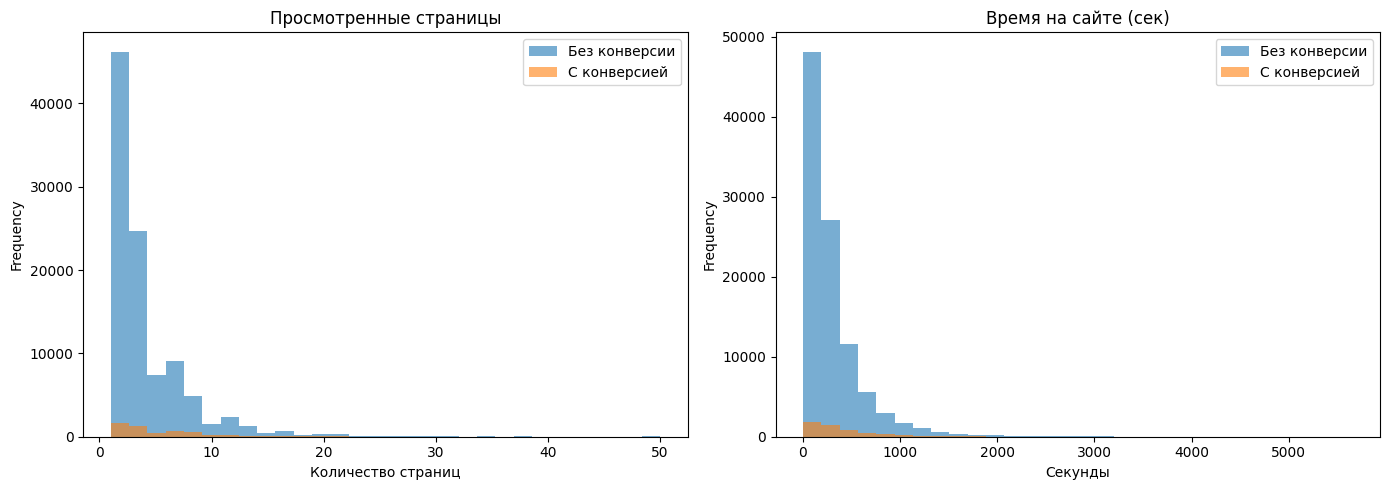

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('conversion')['pages_viewed'].plot(kind='hist', bins=30, alpha=0.6, ax=axes[0])
axes[0].set_title('Просмотренные страницы')
axes[0].set_xlabel('Количество страниц')
axes[0].legend(['Без конверсии', 'С конверсией'])

df.groupby('conversion')['page_duration'].plot(kind='hist', bins=30, alpha=0.6, ax=axes[1])
axes[1].set_title('Время на сайте (сек)')
axes[1].set_xlabel('Секунды')
axes[1].legend(['Без конверсии', 'С конверсией'])

plt.tight_layout()
plt.show()

Пользователи с конверсией просматривают в среднем 5,7 страниц (медиана — 4), без конверсии — 4,0 страницы (медиана — 3).

Медиана времени на сайте у пользователей с конверсией — 307 секунд (5,1 мин), без конверсии — 201 секунда (3,4 мин).

Чем больше времени пользователь проводит на сайте и чем больше страниц просматривает — тем выше вероятность конверсии.

## 9. Корреляционный анализ

In [ ]:
num_cols = ['pages_viewed', 'page_duration', 'conversion']
corr = df[num_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Матрица корреляций')
plt.show()

Выявлена сильная положительная корреляция между количеством просмотренных страниц и временем на сайте (r = 0,888).

Корреляция обеих метрик с конверсией умеренная положительная: `pages_viewed` — 0,087, `page_duration` — 0,077.

## 10. Кластерный анализ пользователей (K-means)

In [14]:
features = df[['pages_viewed', 'page_duration', 'hour']].copy()

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(features_scaled)

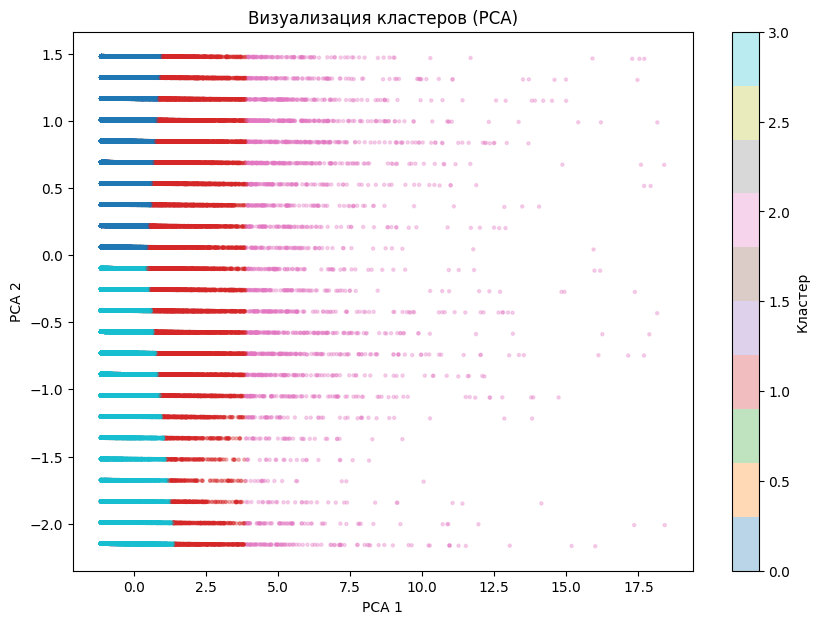

In [15]:
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(features_pca[:, 0], features_pca[:, 1],
                      c=df['cluster'], cmap='tab10', alpha=0.3, s=5)
plt.colorbar(scatter, label='Кластер')
plt.title('Визуализация кластеров (PCA)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.show()

In [16]:
cluster_stats = df.groupby('cluster').agg(
    count=('cluster', 'count'),
    median_pages=('pages_viewed', 'median'),
    median_duration=('page_duration', 'median'),
    typical_hour=('hour', 'median')
)
print(cluster_stats)

         count  median_pages  median_duration  typical_hour
cluster                                                    
0        45653           2.0            164.4          19.0
1        16126           9.0            686.1          15.0
2         2317          20.0           1669.8          15.0
3        41751           2.0            167.6           9.0


Кластерный анализ выявил 4 группы пользователей:

- **Кластер 0 «Глубокие исследователи»** (2,2%): медиана страниц — 20, время — 28 мин, типичный час — 20:00. Наиболее вовлечённая аудитория с высоким потенциалом конверсии.

- **Кластер 1 «Утренние посетители»** (39,4%): медиана страниц — 2, время — 2,8 мин, типичный час — 9:00. Беглые визиты в рабочее время.

- **Кластер 2 «Целенаправленные покупатели»** (15,2%): медиана страниц — 9, время — 11,5 мин, типичный час — 20:00. Активная вечерняя аудитория с чётким намерением покупки.

- **Кластер 3 «Вечерние быстрые посетители»** (43,2%): медиана страниц — 2, время — 2,7 мин, типичный час — 20:00. Крупнейший сегмент — вечерний трафик с низкой вовлечённостью.

## Вывод

В ходе работы проведён комплексный анализ данных о трафике веб-сайта электронной коммерции (105 847 сессий).

Выявленные ключевые паттерны:

- **Временные:** пик активности — 19:00–21:00, конверсия в выходные (6,29%) выше, чем в будни (4,87%). Резкий рост трафика в осенний период (сентябрь–ноябрь).

- **По источникам:** платная реклама лидирует по конверсии (7,66%), социальные сети — по объёму трафика, но с минимальной конверсией (3,00%).

- **По устройствам:** мобильный трафик преобладает (58,3%), но конверсия на десктопе вдвое выше (7,20% против 4,15%).

- **Поведенческие:** сильная корреляция между глубиной просмотра и временем на сайте (r = 0,888). Пользователи с конверсией проводят на сайте в 1,5 раза больше времени.

- **Кластеризация:** выявлены 4 типа пользователей, наиболее ценные из которых — «Глубокие исследователи» и «Целенаправленные покупатели».